# 02 - Phase 1 Screening (4 models x 16 covariates x 2 windows x 2 horizons = 256 experiments)

Tujuan: screening single-covariate untuk mencari covariate mana yang memberi improvement signifikan terhadap baseline (target-only) di 4 model tree-based.

## Desain
- **Models (4):** RandomForest, ExtraTrees, XGBoost, LightGBM
- **Covariates (16):** None (baseline) + 15 single covariates
- **Windows (2):** 30, 120
- **Horizons (2):** 1 hari (next-day), 20 hari (one-month ahead)
- **CV:** 5-fold expanding window
- **Hyperparameters:** default konservatif dari spec (bukan arbitrary)
- **Metric utama:** MAPE di level harga IHSG (bukan log-diff)

## Output
- `phase1_screening_results.csv` - 256 rows, semua metrik per experiment
- `phase1_screening_analysis.csv` - pass/fail per covariate (threshold 0.3% improvement)

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import joblib
import gc
import glob
import traceback
from datetime import datetime
import warnings

from darts import TimeSeries
from darts.models import RandomForestModel, XGBModel, LightGBMModel
from darts.dataprocessing.transformers import Scaler, Diff
from darts.utils.missing_values import fill_missing_values
from sklearn.ensemble import ExtraTreesRegressor

try:
    from darts.models import SKLearnModel
except ImportError:
    from darts.models import RegressionModel as SKLearnModel

warnings.filterwarnings("ignore")

# Auto-load df_merged terbaru (tidak hardcode nama file)
joblib_files = sorted(glob.glob("saved_models/df_merged_*.joblib"), reverse=True)
if not joblib_files:
    raise FileNotFoundError("df_merged_*.joblib tidak ditemukan. Jalankan notebook 00 dulu.")
df_merged = joblib.load(joblib_files[0])
print(f"Loaded: {joblib_files[0]}")

LEVEL_VARS = ["M2", "USDIDR", "Coal", "Copper", "Nickel", "Silver", "Tin", "STI", "Gold", "WTI", "GDP"]
RATE_VARS  = ["BI_Rate", "CPI", "NPL_Ratio", "US_Treasury_10Y"]

print(f"Data: {df_merged.shape} | {df_merged['date'].min().date()} to {df_merged['date'].max().date()}")

Loaded: saved_models\df_merged_20260507_1049.joblib
Data: (2443, 17) | 2015-01-02 to 2025-01-31


## 2. Konfigurasi Eksperimen

In [2]:
SINGLE_COVARIATES = {
    "None":            [],
    # Macro (7)
    "BI_Rate":         ["BI_Rate"],
    "CPI":             ["CPI"],
    "M2":              ["M2"],
    "NPL_Ratio":       ["NPL_Ratio"],
    "USDIDR":          ["USDIDR"],
    "GDP":             ["GDP"],
    "US_Treasury_10Y": ["US_Treasury_10Y"],
    # Commodity (7)
    "Coal":            ["Coal"],
    "Copper":          ["Copper"],
    "Nickel":          ["Nickel"],
    "Silver":          ["Silver"],
    "Tin":             ["Tin"],
    "Gold":            ["Gold"],
    "WTI":             ["WTI"],
    # Regional (1)
    "STI":             ["STI"],
}

WINDOWS  = [20, 120]      # 1 bulan & 6 bulan business day
HORIZONS = [1, 5, 20]     # next-day, 1 minggu, 1 bulan business day
N_FOLDS  = 5

# Default hyperparameters (spec-based, bukan arbitrary)
MODEL_CONFIGS = {
    "RandomForest": {
        "n_estimators": 300,
        "max_depth": 5,
        "max_features": "sqrt",
        "max_samples": 0.7,
    },
    "ExtraTrees": {
        "n_estimators": 300,
        "max_depth": 5,
        "max_features": "sqrt",
    },
    "XGBoost": {
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.1,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
        "reg_alpha": 0.01,
        "reg_lambda": 1.0,
    },
    "LightGBM": {
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.1,
        "num_leaves": 31,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
        "reg_alpha": 0.01,
        "reg_lambda": 1.0,
    },
}

total_exp = len(MODEL_CONFIGS) * len(SINGLE_COVARIATES) * len(WINDOWS) * len(HORIZONS)
print(f"Models    : {list(MODEL_CONFIGS.keys())}")
print(f"Covariates: {len(SINGLE_COVARIATES)} configs")
print(f"Windows   : {WINDOWS}")
print(f"Horizons  : {HORIZONS}")
print(f"Total experiments: {total_exp}")


Models    : ['RandomForest', 'ExtraTrees', 'XGBoost', 'LightGBM']
Covariates: 16 configs
Windows   : [20, 120]
Horizons  : [1, 5, 20]
Total experiments: 384


## 3. Helper Functions

In [3]:
def to_series(df, target_col, covariates=None):
    """Convert DataFrame to Darts TimeSeries (target + optional covariates)."""
    target = TimeSeries.from_dataframe(
        df, time_col="date", value_cols=target_col,
        fill_missing_dates=True, freq="B",
    )
    target = fill_missing_values(target)
    cov = None
    if covariates:
        cov = TimeSeries.from_dataframe(
            df, time_col="date", value_cols=covariates,
            fill_missing_dates=True, freq="B",
        )
        cov = fill_missing_values(cov)
    return target, cov


def build_model(model_name, window, horizon, has_covariates):
    """Factory: build a Darts model dengan window dan horizon yang ditentukan."""
    params = MODEL_CONFIGS[model_name]
    common = {
        "lags": window,
        "lags_past_covariates": window if has_covariates else None,
        "output_chunk_length": horizon,
    }
    if model_name == "RandomForest":
        return RandomForestModel(**common, random_state=42, n_jobs=-1, **params)
    elif model_name == "ExtraTrees":
        return SKLearnModel(
            **common,
            model=ExtraTreesRegressor(random_state=42, n_jobs=-1, **params),
        )
    elif model_name == "XGBoost":
        return XGBModel(**common, random_state=42, n_jobs=-1, **params)
    elif model_name == "LightGBM":
        return LightGBMModel(**common, random_state=42, n_jobs=-1, verbose=-1, **params)
    else:
        raise ValueError(f"Unknown model: {model_name}")


print("Helpers defined")

Helpers defined


## 4. Evaluate Function (5-fold Expanding CV, MAPE on Level)

Pipeline per fold:
1. Split expanding: train[:train_end], test[train_end:test_end]
2. Transform target: `log -> Diff(1) -> Scaler` (fit on train)
3. Transform covariates: `log -> Diff(1)` untuk LEVEL_VARS, `Diff(1)` untuk RATE_VARS, lalu `Scaler`
4. Fit model on train, historical forecast on test window
5. Inverse: scaler -> log-diff -> cumsum dari anchor -> exp -> harga level
6. Compute metrics: MAPE, MAE, RMSE, R2, DA


In [4]:
def train_and_evaluate(model_name, target_ts, cov_ts, window, horizon, n_folds=N_FOLDS):
    """5-fold expanding CV. Returns dict of per-fold metrics."""
    n = len(target_ts)
    test_size = int(n * 0.15)
    min_train = int(n * 0.4)
    available = n - min_train - test_size
    step = max(1, available // max(1, n_folds - 1))

    fold_metrics = {"mape": [], "mae": [], "rmse": [], "r2": [], "da": []}

    for fold in range(n_folds):
        train_end = min_train + fold * step
        test_end = min(train_end + test_size, n)
        if test_end > n or train_end >= test_end:
            break

        train_ts = target_ts[:train_end]
        test_ts  = target_ts[train_end:test_end]
        fold_ts  = target_ts[:test_end]

        # Target transform: log -> diff -> scale (fit on train)
        train_log = train_ts.map(np.log)
        fold_log  = fold_ts.map(np.log)
        differencer = Diff(lags=1)
        train_log_diff = differencer.fit_transform(train_log)
        fold_log_diff  = differencer.transform(fold_log)
        scaler = Scaler()
        train_scaled = scaler.fit_transform(train_log_diff)
        fold_scaled  = scaler.transform(fold_log_diff)

        # Covariate transform
        cov_transformed = None
        if cov_ts is not None:
            cov_fold  = cov_ts[:test_end]
            cov_train = cov_ts[:train_end]
            cov_cols   = cov_ts.components.tolist()
            level_cols = [c for c in cov_cols if c in LEVEL_VARS]
            rate_cols  = [c for c in cov_cols if c in RATE_VARS]

            parts_train, parts_fold = [], []
            if level_cols:
                d1 = Diff(lags=1)
                parts_train.append(d1.fit_transform(cov_train[level_cols].map(np.log)))
                parts_fold.append(d1.transform(cov_fold[level_cols].map(np.log)))
            if rate_cols:
                d2 = Diff(lags=1)
                parts_train.append(d2.fit_transform(cov_train[rate_cols]))
                parts_fold.append(d2.transform(cov_fold[rate_cols]))

            ct = parts_train[0]
            cf = parts_fold[0]
            for pt, pf in zip(parts_train[1:], parts_fold[1:]):
                ct = ct.stack(pt)
                cf = cf.stack(pf)

            cov_scaler = Scaler()
            cov_scaler.fit(ct)
            cov_transformed = cov_scaler.transform(cf)

        # Fit model (sekarang terima horizon)
        model = build_model(model_name, window, horizon, has_covariates=(cov_ts is not None))
        model.fit(train_scaled, past_covariates=cov_transformed)

        # Historical forecast — stride = horizon agar non-overlapping
        forecast_list = model.historical_forecasts(
            series=fold_scaled,
            past_covariates=cov_transformed,
            start=test_ts.start_time(),
            forecast_horizon=horizon,
            stride=horizon,
            retrain=False,
            last_points_only=False,
            verbose=False,
        )
        if isinstance(forecast_list, TimeSeries):
            forecast_list = [forecast_list]

        # Inverse transform ke level harga IHSG
        all_dates, all_prices = [], []
        fold_log_full = fold_ts.map(np.log)
        for chunk_scaled in forecast_list:
            chunk_diff = scaler.inverse_transform(chunk_scaled)
            dates = chunk_diff.time_index
            vals  = chunk_diff.values().flatten()
            idx   = fold_ts.get_index_at_point(dates[0])
            if idx == 0:
                continue
            anchor     = fold_log_full[idx - 1].values()[0][0]
            log_prices = anchor + np.cumsum(vals)
            all_dates.extend(dates)
            all_prices.extend(np.exp(log_prices))

        # Metrics
        pred_df   = pd.DataFrame({"date": pd.to_datetime(all_dates), "predicted": all_prices})
        actual_df = fold_ts.to_dataframe().reset_index()
        actual_df.columns = ["date", "actual"]
        eval_df = pd.merge(actual_df, pred_df, on="date", how="inner")
        y_true  = eval_df["actual"].values
        y_pred  = eval_df["predicted"].values

        mape   = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        mae    = np.mean(np.abs(y_true - y_pred))
        rmse   = np.sqrt(np.mean((y_true - y_pred) ** 2))
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - y_true.mean()) ** 2)
        r2     = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
        actual_dir = np.diff(y_true)
        pred_dir   = y_pred[1:] - y_true[:-1]
        da = np.mean((actual_dir > 0) == (pred_dir > 0)) * 100 if len(actual_dir) > 0 else np.nan

        fold_metrics["mape"].append(mape)
        fold_metrics["mae"].append(mae)
        fold_metrics["rmse"].append(rmse)
        fold_metrics["r2"].append(r2)
        fold_metrics["da"].append(da)

        del model
        gc.collect()

    return fold_metrics


print("Evaluation function defined")

Evaluation function defined


## 5. Run Experiment Loop (128 experiments)

In [5]:
results = []
start_time = datetime.now()
exp_num = 0
print(f"Phase 1 Screening started: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total experiments: {total_exp}")
print("=" * 75)

for model_name in MODEL_CONFIGS.keys():
    for cov_name, cov_vars in SINGLE_COVARIATES.items():
        for window in WINDOWS:
            for horizon in HORIZONS:
                exp_num += 1
                tag = f"[{exp_num}/{total_exp}] {model_name:13s} | {cov_name:16s} | W{window}_H{horizon}"
                try:
                    target_ts, cov_ts = to_series(
                        df_merged, "IHSG", cov_vars if cov_vars else None
                    )
                    fm = train_and_evaluate(model_name, target_ts, cov_ts, window, horizon)

                    row = {
                        "Model":     model_name,
                        "Covariates": cov_name,
                        "Window":    window,
                        "Horizon":   horizon,
                        "MAPE_mean": round(np.mean(fm["mape"]), 4),
                        "MAPE_std":  round(np.std(fm["mape"]), 4),
                        "MAE_mean":  round(np.mean(fm["mae"]), 4),
                        "RMSE_mean": round(np.mean(fm["rmse"]), 4),
                        "RMSE_std":  round(np.std(fm["rmse"]), 4),
                        "R2_mean":   round(np.mean(fm["r2"]), 4),
                        "DA_mean":   round(np.mean(fm["da"]), 2),
                        "DA_std":    round(np.std(fm["da"]), 2),
                    }
                    results.append(row)
                    print(f"{tag} -> MAPE={row['MAPE_mean']:.4f}+-{row['MAPE_std']:.4f}% | DA={row['DA_mean']:.1f}%")
                except Exception as e:
                    print(f"{tag} -> ERROR: {e}")
                    traceback.print_exc()
                    results.append({
                        "Model": model_name, "Covariates": cov_name,
                        "Window": window, "Horizon": horizon, "Error": str(e),
                    })

elapsed = datetime.now() - start_time
print("=" * 75)
print(f"Done in {elapsed}")

df_results = pd.DataFrame(results)
df_results.to_csv("phase1_screening_results.csv", index=False)
print(f"Saved: phase1_screening_results.csv ({len(df_results)} rows)")
display(df_results.sort_values("MAPE_mean").head(20))

Phase 1 Screening started: 2026-05-07 14:25:33
Total experiments: 384
[1/384] RandomForest  | None             | W20_H1 -> MAPE=0.6611+-0.1656% | DA=52.0%
[2/384] RandomForest  | None             | W20_H5 -> MAPE=1.0884+-0.3449% | DA=50.8%
[3/384] RandomForest  | None             | W20_H20 -> MAPE=2.0972+-0.5936% | DA=49.7%
[4/384] RandomForest  | None             | W120_H1 -> MAPE=0.6626+-0.1674% | DA=52.4%
[5/384] RandomForest  | None             | W120_H5 -> MAPE=1.0882+-0.3453% | DA=50.6%
[6/384] RandomForest  | None             | W120_H20 -> MAPE=2.1073+-0.6093% | DA=50.2%
[7/384] RandomForest  | BI_Rate          | W20_H1 -> MAPE=0.6620+-0.1658% | DA=51.1%
[8/384] RandomForest  | BI_Rate          | W20_H5 -> MAPE=1.0884+-0.3447% | DA=50.8%
[9/384] RandomForest  | BI_Rate          | W20_H20 -> MAPE=2.0962+-0.5940% | DA=50.0%
[10/384] RandomForest  | BI_Rate          | W120_H1 -> MAPE=0.6627+-0.1683% | DA=50.2%
[11/384] RandomForest  | BI_Rate          | W120_H5 -> MAPE=1.0880+-0.34

,Model,Covariates,Window,Horizon,MAPE_mean,MAPE_std,MAE_mean,RMSE_mean,RMSE_std,R2_mean,DA_mean,DA_std
150,ExtraTrees,Copper,20,1,0.6577,0.1623,40.2312,55.0499,9.3623,0.9692,53.08,1.16
162,ExtraTrees,Silver,20,1,0.6579,0.1634,40.2359,55.0106,9.3591,0.9692,54.66,2.40
165,ExtraTrees,Silver,120,1,0.6586,0.1634,40.2849,55.0116,9.2925,0.9691,53.23,1.90
183,ExtraTrees,WTI,120,1,0.6586,0.1629,40.2885,55.0556,9.2997,0.9691,52.16,2.00
135,ExtraTrees,GDP,120,1,0.6587,0.1633,40.2862,55.0826,9.3521,0.9691,52.52,1.83
66,RandomForest,Silver,20,1,0.6588,0.1649,40.2801,55.2407,9.7080,0.9692,53.74,3.00
126,ExtraTrees,USDIDR,20,1,0.6589,0.1627,40.3023,55.1647,9.3911,0.9690,53.08,0.26
111,ExtraTrees,CPI,120,1,0.6590,0.1629,40.3148,55.1087,9.3155,0.9690,51.76,2.17
177,ExtraTrees,Gold,120,1,0.6590,0.1637,40.3055,55.0800,9.3509,0.9691,52.57,2.44
153,ExtraTrees,Copper,120,1,0.6590,0.1633,40.3079,55.0752,9.3508,0.9691,52.57,1.60


## 6. Screening Analysis

Covariate dianggap "lolos" kalau improvement MAPE terhadap baseline (`None`) >= threshold. Default threshold = **0.3%** (relative improvement).


In [6]:
def analyze_screening(df, threshold_pct=0.3):
    rows = []
    for model_name in df["Model"].unique():
        for window in df["Window"].unique():
            for horizon in df["Horizon"].unique():
                mask = (
                    (df["Model"]   == model_name) &
                    (df["Window"]  == window) &
                    (df["Horizon"] == horizon)
                )
                subset = df[mask]
                baseline_row = subset[subset["Covariates"] == "None"]
                if baseline_row.empty or "MAPE_mean" not in baseline_row.columns:
                    continue
                baseline_mape = baseline_row["MAPE_mean"].values[0]

                for _, row in subset.iterrows():
                    if row["Covariates"] == "None":
                        continue
                    if pd.isna(row.get("MAPE_mean")):
                        continue
                    impr = (baseline_mape - row["MAPE_mean"]) / baseline_mape * 100
                    rows.append({
                        "Model":          model_name,
                        "Window":         window,
                        "Horizon":        horizon,
                        "Covariate":      row["Covariates"],
                        "MAPE":           row["MAPE_mean"],
                        "Baseline_MAPE":  baseline_mape,
                        "Improvement_pct": round(impr, 3),
                        "Passed":         impr >= threshold_pct,
                    })
    return pd.DataFrame(rows)


df_screening = analyze_screening(df_results, threshold_pct=0.3)
df_screening.to_csv("phase1_screening_analysis.csv", index=False)
print(f"Saved: phase1_screening_analysis.csv ({len(df_screening)} rows)")

# Pass counts (out of 4 models x 2 windows x 2 horizons = 16 combos)
max_combos = df_results["Model"].nunique() * df_results["Window"].nunique() * df_results["Horizon"].nunique()
pass_counts = (
    df_screening[df_screening["Passed"]]
    .groupby("Covariate").size()
    .sort_values(ascending=False)
    .rename("pass_count")
    .to_frame()
)
pass_counts["pass_rate"] = (pass_counts["pass_count"] / max_combos * 100).round(1)
print(f"\nCovariate pass counts (out of {max_combos} model x window x horizon combos):")
display(pass_counts)

# Ringkasan per horizon
print("\nPass counts breakdown per Horizon:")
for h in sorted(df_screening["Horizon"].unique()):
    sub = df_screening[df_screening["Horizon"] == h]
    pc  = sub[sub["Passed"]].groupby("Covariate").size().sort_values(ascending=False)
    max_h = df_results["Model"].nunique() * df_results["Window"].nunique()
    print(f"\n  H{h} (max {max_h} combos):")
    print(f"  {pc.to_dict()}")

Saved: phase1_screening_analysis.csv (360 rows)

Covariate pass counts (out of 24 model x window x horizon combos):


,pass_count,pass_rate
Covariate,,
Silver,14,58.3
STI,11,45.8
Gold,10,41.7
Copper,10,41.7
M2,9,37.5
WTI,9,37.5
NPL_Ratio,8,33.3
USDIDR,7,29.2
CPI,6,25.0



Pass counts breakdown per Horizon:

  H1 (max 8 combos):
  {'Silver': 5, 'Copper': 4, 'USDIDR': 4, 'M2': 3, 'STI': 3, 'Nickel': 2, 'BI_Rate': 2, 'CPI': 2, 'Gold': 2, 'NPL_Ratio': 2, 'WTI': 2, 'GDP': 1}

  H5 (max 8 combos):
  {'Gold': 5, 'STI': 5, 'Silver': 5, 'M2': 4, 'GDP': 3, 'NPL_Ratio': 3, 'Copper': 3, 'BI_Rate': 2, 'CPI': 2, 'Tin': 2, 'Coal': 1, 'USDIDR': 1, 'WTI': 1}

  H20 (max 8 combos):
  {'WTI': 6, 'Silver': 4, 'Copper': 3, 'Gold': 3, 'STI': 3, 'NPL_Ratio': 3, 'CPI': 2, 'GDP': 2, 'USDIDR': 2, 'M2': 2, 'BI_Rate': 1, 'Tin': 1}


In [17]:
pd.set_option("display.max_rows", None)
df_screening

,Model,Window,Horizon,Covariate,MAPE,Baseline_MAPE,Improvement_pct,Passed
0,RandomForest,20,1,BI_Rate,0.6620,0.6611,-0.136,False
1,RandomForest,20,1,CPI,0.6607,0.6611,0.061,False
2,RandomForest,20,1,M2,0.6608,0.6611,0.045,False
3,RandomForest,20,1,NPL_Ratio,0.6608,0.6611,0.045,False
4,RandomForest,20,1,USDIDR,0.6604,0.6611,0.106,False
5,RandomForest,20,1,GDP,0.6612,0.6611,-0.015,False
6,RandomForest,20,1,US_Treasury_10Y,0.6636,0.6611,-0.378,False
7,RandomForest,20,1,Coal,0.6621,0.6611,-0.151,False
8,RandomForest,20,1,Copper,0.6606,0.6611,0.076,False
9,RandomForest,20,1,Nickel,0.6618,0.6611,-0.106,False


In [8]:
pd.set_option("display.max_rows", None)

df_screening

,Model,Window,Horizon,Covariate,MAPE,Baseline_MAPE,Improvement_pct,Passed
0,RandomForest,20,1,BI_Rate,0.6620,0.6611,-0.136,False
1,RandomForest,20,1,CPI,0.6607,0.6611,0.061,False
2,RandomForest,20,1,M2,0.6608,0.6611,0.045,False
3,RandomForest,20,1,NPL_Ratio,0.6608,0.6611,0.045,False
4,RandomForest,20,1,USDIDR,0.6604,0.6611,0.106,False
5,RandomForest,20,1,GDP,0.6612,0.6611,-0.015,False
6,RandomForest,20,1,US_Treasury_10Y,0.6636,0.6611,-0.378,False
7,RandomForest,20,1,Coal,0.6621,0.6611,-0.151,False
8,RandomForest,20,1,Copper,0.6606,0.6611,0.076,False
9,RandomForest,20,1,Nickel,0.6618,0.6611,-0.106,False


## 7. Enhanced Screening — MAPE + DA + Consistency

Untuk memperkuat bukti pengaruh covariate, digunakan tiga kriteria:

| Kriteria | Threshold | Alasan |
|---|---|---|
| **MAPE Improvement** | ≥ 0.3% relatif | Akurasi prediksi level harga |
| **DA Improvement** | ≥ 1.0 pp | Arah prediksi naik/turun — lebih visible di H1, bermakna praktis |
| **Consistency Score** | improvement / std | Mengukur seberapa konsisten improvement antar fold |

Covariate lolos jika **memenuhi ≥ 1 kriteria** (MAPE atau DA).

In [9]:
MAPE_THRESHOLD = 0.3   # % relative improvement
DA_THRESHOLD   = 1.0   # percentage point improvement in directional accuracy

def analyze_screening_enhanced(df, mape_threshold=MAPE_THRESHOLD, da_threshold=DA_THRESHOLD):
    rows = []
    for model_name in df["Model"].unique():
        for window in df["Window"].unique():
            for horizon in df["Horizon"].unique():
                mask = (
                    (df["Model"]   == model_name) &
                    (df["Window"]  == window) &
                    (df["Horizon"] == horizon)
                )
                subset = df[mask]
                bl = subset[subset["Covariates"] == "None"]
                if bl.empty or "MAPE_mean" not in bl.columns:
                    continue
                bl_mape = bl["MAPE_mean"].values[0]
                bl_da   = bl["DA_mean"].values[0] if "DA_mean" in bl.columns else np.nan

                for _, row in subset.iterrows():
                    if row["Covariates"] == "None" or pd.isna(row.get("MAPE_mean")):
                        continue

                    mape_impr = (bl_mape - row["MAPE_mean"]) / bl_mape * 100
                    da_impr   = row["DA_mean"] - bl_da if not np.isnan(bl_da) else np.nan

                    # Consistency: MAPE absolute improvement dibagi std-nya
                    # Positif & besar = improvement konsisten antar fold
                    abs_impr    = bl_mape - row["MAPE_mean"]
                    consistency = abs_impr / row["MAPE_std"] if row.get("MAPE_std", 0) > 0 else 0.0

                    passed_mape = mape_impr >= mape_threshold
                    passed_da   = (not np.isnan(da_impr)) and (da_impr >= da_threshold)

                    rows.append({
                        "Model":              model_name,
                        "Window":             window,
                        "Horizon":            horizon,
                        "Covariate":          row["Covariates"],
                        "MAPE":               row["MAPE_mean"],
                        "Baseline_MAPE":      bl_mape,
                        "MAPE_Impr_pct":      round(mape_impr, 3),
                        "DA":                 row["DA_mean"],
                        "Baseline_DA":        round(bl_da, 2),
                        "DA_Impr_pp":         round(da_impr, 2),
                        "Consistency":        round(consistency, 3),
                        "Passed_MAPE":        passed_mape,
                        "Passed_DA":          passed_da,
                        "Passed_Any":         passed_mape or passed_da,
                        "Passed_Both":        passed_mape and passed_da,
                    })
    return pd.DataFrame(rows)


df_enh = analyze_screening_enhanced(df_results)
df_enh.to_csv("phase1_screening_enhanced.csv", index=False)
print(f"Saved: phase1_screening_enhanced.csv ({len(df_enh)} rows)")
print(f"\nThresholds: MAPE ≥ {MAPE_THRESHOLD}% | DA ≥ +{DA_THRESHOLD} pp")
display(df_enh.head(10))

Saved: phase1_screening_enhanced.csv (360 rows)

Thresholds: MAPE ≥ 0.3% | DA ≥ +1.0 pp


,Model,Window,Horizon,Covariate,MAPE,Baseline_MAPE,MAPE_Impr_pct,DA,Baseline_DA,DA_Impr_pp,Consistency,Passed_MAPE,Passed_DA,Passed_Any,Passed_Both
0,RandomForest,20,1,BI_Rate,0.6620,0.6611,-0.136,51.09,51.96,-0.87,-0.005,False,False,False,False
1,RandomForest,20,1,CPI,0.6607,0.6611,0.061,53.28,51.96,1.32,0.002,False,True,True,False
2,RandomForest,20,1,M2,0.6608,0.6611,0.045,53.03,51.96,1.07,0.002,False,True,True,False
3,RandomForest,20,1,NPL_Ratio,0.6608,0.6611,0.045,52.32,51.96,0.36,0.002,False,False,False,False
4,RandomForest,20,1,USDIDR,0.6604,0.6611,0.106,53.54,51.96,1.58,0.004,False,True,True,False
5,RandomForest,20,1,GDP,0.6612,0.6611,-0.015,52.37,51.96,0.41,-0.001,False,False,False,False
6,RandomForest,20,1,US_Treasury_10Y,0.6636,0.6611,-0.378,51.60,51.96,-0.36,-0.016,False,False,False,False
7,RandomForest,20,1,Coal,0.6621,0.6611,-0.151,51.35,51.96,-0.61,-0.006,False,False,False,False
8,RandomForest,20,1,Copper,0.6606,0.6611,0.076,52.21,51.96,0.25,0.003,False,False,False,False
9,RandomForest,20,1,Nickel,0.6618,0.6611,-0.106,51.96,51.96,0.00,-0.004,False,False,False,False


In [10]:
max_combos = df_results["Model"].nunique() * df_results["Window"].nunique() * df_results["Horizon"].nunique()
max_h1     = df_results["Model"].nunique() * df_results["Window"].nunique()

# --- Ranking tabel per covariate ---
ranking = (
    df_enh.groupby("Covariate")
    .agg(
        pass_mape   = ("Passed_MAPE",    "sum"),
        pass_da     = ("Passed_DA",      "sum"),
        pass_any    = ("Passed_Any",     "sum"),
        pass_both   = ("Passed_Both",    "sum"),
        avg_mape_impr = ("MAPE_Impr_pct", "mean"),
        avg_da_impr   = ("DA_Impr_pp",    "mean"),
        avg_consistency = ("Consistency", "mean"),
    )
    .assign(
        pass_rate_any  = lambda x: (x["pass_any"]  / max_combos * 100).round(1),
        pass_rate_both = lambda x: (x["pass_both"] / max_combos * 100).round(1),
        avg_mape_impr  = lambda x: x["avg_mape_impr"].round(3),
        avg_da_impr    = lambda x: x["avg_da_impr"].round(2),
        avg_consistency= lambda x: x["avg_consistency"].round(3),
    )
    .sort_values("pass_any", ascending=False)
)

print(f"=== COVARIATE RANKING (out of {max_combos} combos) ===")
print(f"Threshold: MAPE ≥ {MAPE_THRESHOLD}% | DA ≥ +{DA_THRESHOLD} pp\n")
display(ranking[[
    "pass_mape", "pass_da", "pass_any", "pass_rate_any",
    "avg_mape_impr", "avg_da_impr", "avg_consistency"
]].rename(columns={
    "pass_mape":       "Pass (MAPE)",
    "pass_da":         "Pass (DA)",
    "pass_any":        "Pass (Any)",
    "pass_rate_any":   "Pass Rate %",
    "avg_mape_impr":   "Avg MAPE Impr%",
    "avg_da_impr":     "Avg DA Impr pp",
    "avg_consistency": "Avg Consistency",
}))

# --- H1 vs H20 breakdown ---
print("\n=== BREAKDOWN PER HORIZON ===")
for h in sorted(df_enh["Horizon"].unique()):
    sub     = df_enh[df_enh["Horizon"] == h]
    max_sub = df_results["Model"].nunique() * df_results["Window"].nunique()
    rank_h  = (
        sub.groupby("Covariate")
        .agg(pass_mape=("Passed_MAPE","sum"), pass_da=("Passed_DA","sum"), pass_any=("Passed_Any","sum"),
             avg_mape_impr=("MAPE_Impr_pct","mean"), avg_da_impr=("DA_Impr_pp","mean"))
        .assign(avg_mape_impr=lambda x: x["avg_mape_impr"].round(3),
                avg_da_impr=lambda x: x["avg_da_impr"].round(2))
        .sort_values("pass_any", ascending=False)
    )
    note = "(MAPE diff kecil, DA lebih informatif)" if h == 1 else "(MAPE diff lebih visible)"
    print(f"\n  Horizon H{h} — max {max_sub} combos {note}")
    display(rank_h)

=== COVARIATE RANKING (out of 24 combos) ===
Threshold: MAPE ≥ 0.3% | DA ≥ +1.0 pp



,Pass (MAPE),Pass (DA),Pass (Any),Pass Rate %,Avg MAPE Impr%,Avg DA Impr pp,Avg Consistency
Covariate,,,,,,,
Silver,14,8,15,62.5,0.113,0.48,0.002
STI,11,7,14,58.3,0.398,0.28,0.015
Copper,10,6,11,45.8,0.498,0.32,0.020
Gold,10,4,11,45.8,0.760,0.06,0.029
M2,9,5,10,41.7,0.104,0.09,0.002
USDIDR,7,5,9,37.5,0.119,0.15,0.006
WTI,9,0,9,37.5,0.240,-0.27,0.008
NPL_Ratio,8,4,8,33.3,0.075,-0.14,0.002
CPI,6,3,8,33.3,0.026,0.07,0.001



=== BREAKDOWN PER HORIZON ===

  Horizon H1 — max 8 combos (MAPE diff kecil, DA lebih informatif)


,pass_mape,pass_da,pass_any,avg_mape_impr,avg_da_impr
Covariate,,,,,
Silver,5,6,6,0.367,1.40
USDIDR,4,4,6,0.510,0.52
STI,3,4,5,0.453,0.70
M2,3,3,4,0.229,0.30
Copper,4,3,4,0.296,0.29
Gold,2,2,3,0.468,-0.12
CPI,2,2,3,0.209,0.45
NPL_Ratio,2,2,2,0.107,0.09
GDP,1,2,2,0.185,0.32



  Horizon H5 — max 8 combos (MAPE diff lebih visible)


,pass_mape,pass_da,pass_any,avg_mape_impr,avg_da_impr
Covariate,,,,,
Gold,5,0,5,1.721,-0.10
STI,5,1,5,0.902,0.04
Silver,5,0,5,0.586,-0.24
Copper,3,2,4,0.398,0.39
M2,4,1,4,0.032,-0.27
GDP,3,1,3,0.302,-0.16
NPL_Ratio,3,0,3,0.129,-0.47
BI_Rate,2,0,2,0.339,0.02
CPI,2,0,2,0.257,-0.18



  Horizon H20 — max 8 combos (MAPE diff lebih visible)


,pass_mape,pass_da,pass_any,avg_mape_impr,avg_da_impr
Covariate,,,,,
WTI,6,0,6,0.941,0.16
Silver,4,2,4,-0.614,0.28
STI,3,2,4,-0.163,0.08
Gold,3,2,3,0.092,0.39
CPI,2,1,3,-0.388,-0.06
GDP,2,2,3,-0.013,0.21
Copper,3,1,3,0.799,0.28
NPL_Ratio,3,2,3,-0.013,-0.03
USDIDR,2,1,2,-0.143,0.09


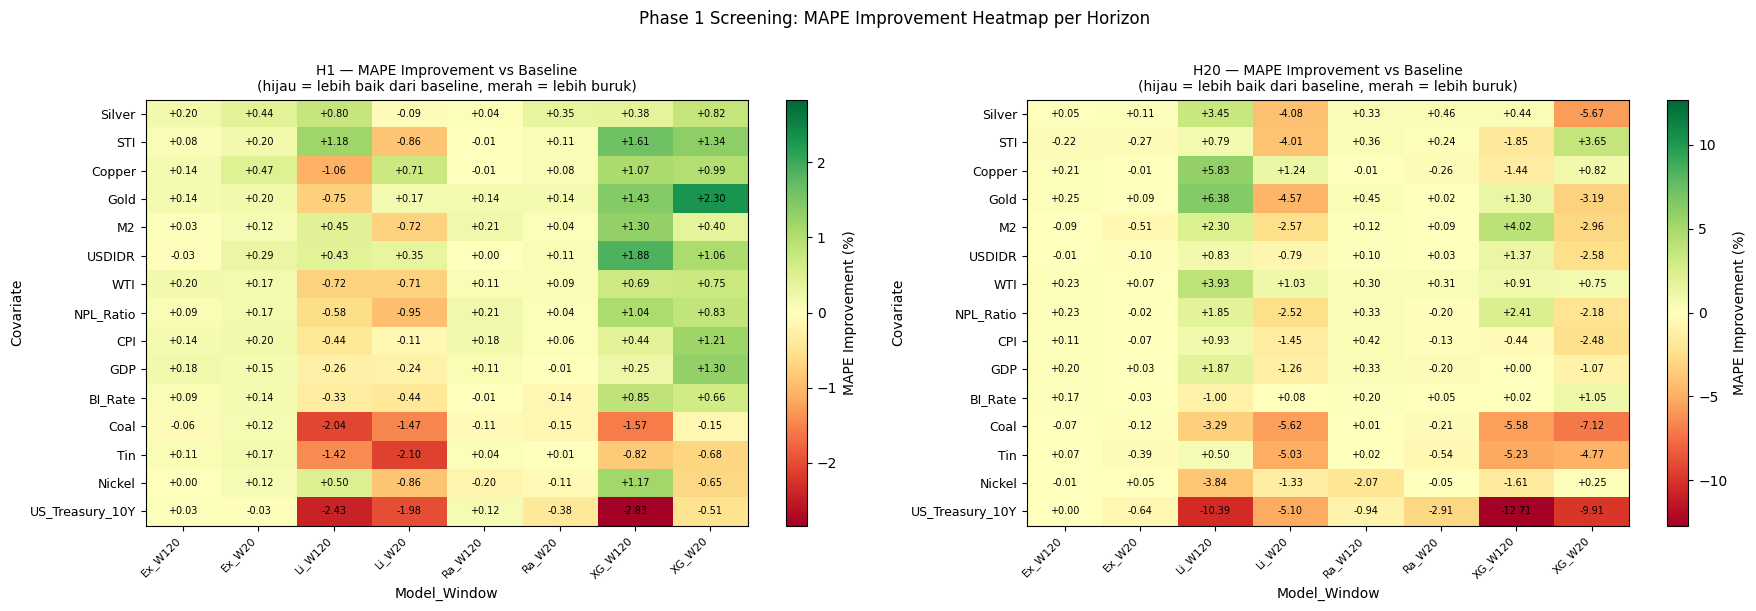

Saved: phase1_heatmap_mape.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

COV_ORDER = (
    ranking.index.tolist()
)

for ax, horizon in zip(axes, [1, 20]):
    sub = df_enh[df_enh["Horizon"] == horizon].copy()

    # Pivot: baris = covariate, kolom = Model_Window, nilai = MAPE_Impr_pct
    sub["combo"] = sub["Model"].str[:2] + "_W" + sub["Window"].astype(str)
    pivot = sub.pivot_table(index="Covariate", columns="combo", values="MAPE_Impr_pct")
    pivot = pivot.reindex(COV_ORDER).dropna(how="all")

    # Tambah kolom DA_Impr rata-rata
    da_avg = sub.groupby("Covariate")["DA_Impr_pp"].mean().reindex(pivot.index)

    # Heatmap MAPE improvement
    vmax = max(abs(pivot.values[~np.isnan(pivot.values)]).max(), 0.5)
    im = ax.imshow(
        pivot.values, aspect="auto",
        cmap="RdYlGn", vmin=-vmax, vmax=vmax
    )
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)

    # Anotasi nilai + tanda pass
    for i in range(len(pivot.index)):
        cov = pivot.index[i]
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if np.isnan(val):
                continue
            # Cek DA pass untuk covariate ini
            da_val = da_avg.iloc[i]
            txt = f"{val:+.2f}"
            color = "black"
            ax.text(j, i, txt, ha="center", va="center", fontsize=7, color=color)

    plt.colorbar(im, ax=ax, label="MAPE Improvement (%)")
    ax.set_title(
        f"H{horizon} — MAPE Improvement vs Baseline\n"
        f"(hijau = lebih baik dari baseline, merah = lebih buruk)",
        fontsize=10
    )
    ax.set_xlabel("Model_Window")
    ax.set_ylabel("Covariate")

plt.suptitle("Phase 1 Screening: MAPE Improvement Heatmap per Horizon", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("phase1_heatmap_mape.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: phase1_heatmap_mape.png")

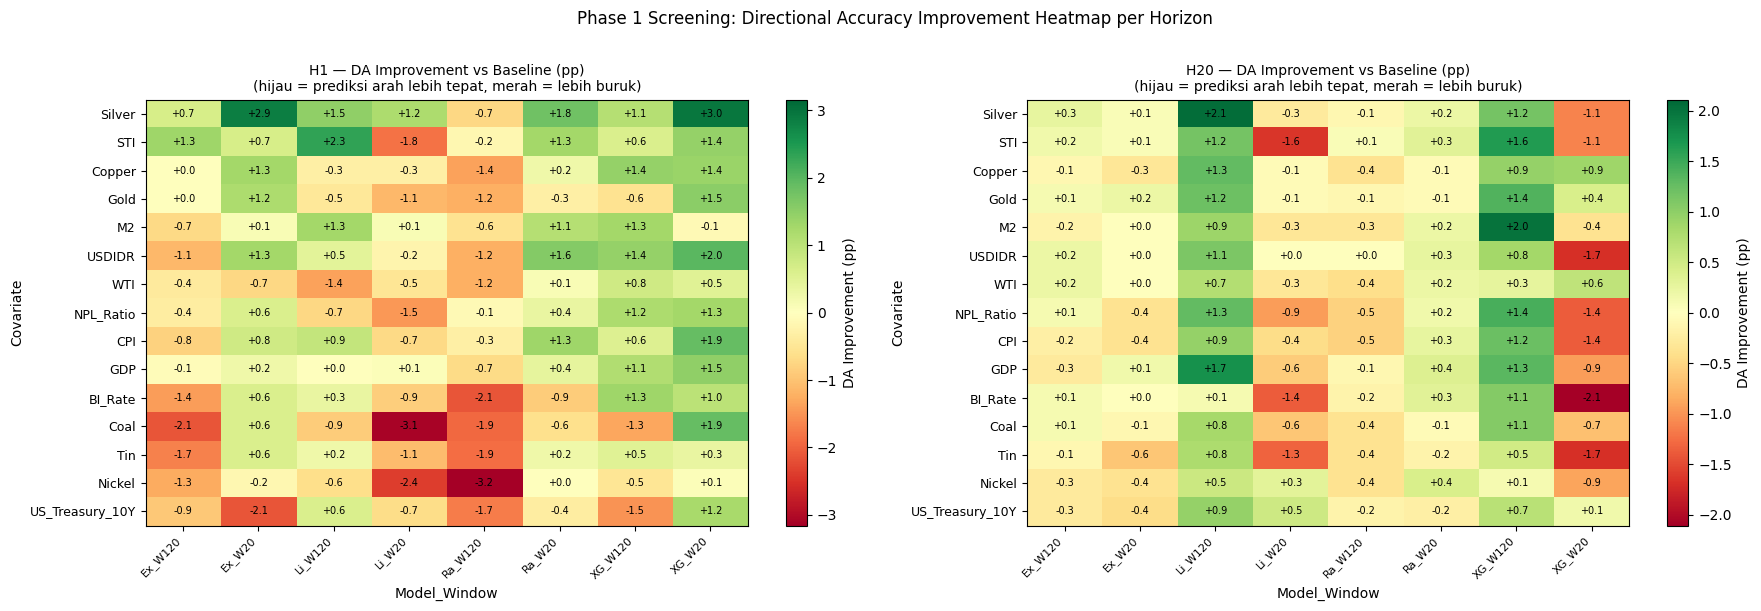

Saved: phase1_heatmap_da.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, horizon in zip(axes, [1, 20]):
    sub = df_enh[df_enh["Horizon"] == horizon].copy()
    sub["combo"] = sub["Model"].str[:2] + "_W" + sub["Window"].astype(str)
    pivot = sub.pivot_table(index="Covariate", columns="combo", values="DA_Impr_pp")
    pivot = pivot.reindex(COV_ORDER).dropna(how="all")

    vmax = max(abs(pivot.values[~np.isnan(pivot.values)]).max(), 1.0)
    im = ax.imshow(
        pivot.values, aspect="auto",
        cmap="RdYlGn", vmin=-vmax, vmax=vmax
    )
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if np.isnan(val):
                continue
            ax.text(j, i, f"{val:+.1f}", ha="center", va="center", fontsize=7, color="black")

    plt.colorbar(im, ax=ax, label="DA Improvement (pp)")
    ax.set_title(
        f"H{horizon} — DA Improvement vs Baseline (pp)\n"
        f"(hijau = prediksi arah lebih tepat, merah = lebih buruk)",
        fontsize=10
    )
    ax.set_xlabel("Model_Window")
    ax.set_ylabel("Covariate")

plt.suptitle("Phase 1 Screening: Directional Accuracy Improvement Heatmap per Horizon", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("phase1_heatmap_da.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: phase1_heatmap_da.png")

In [13]:
# Ringkasan final: covariate lolos enhanced screening
final_pass = ranking[ranking["pass_any"] > 0].copy()

print("=== REKOMENDASI COVARIATE UNTUK PHASE 2 ===")
print(f"(lolos ≥1 kriteria dari {max_combos} kombinasi model×window×horizon)\n")

tiers = {
    "Tier 1 — Kuat (pass_any ≥ 10)": final_pass[final_pass["pass_any"] >= 10],
    "Tier 2 — Moderat (pass_any 5-9)": final_pass[(final_pass["pass_any"] >= 5) & (final_pass["pass_any"] < 10)],
    "Tier 3 — Lemah (pass_any < 5)":  final_pass[final_pass["pass_any"] < 5],
}

for label, tier_df in tiers.items():
    if tier_df.empty:
        continue
    print(f"\n{label}:")
    for cov, row in tier_df.iterrows():
        print(
            f"  {cov:18s} | Pass MAPE={int(row['pass_mape']):<2} DA={int(row['pass_da']):<2} Any={int(row['pass_any']):<2} "
            f"| AvgMAPEImpr={row['avg_mape_impr']:+.3f}%  AvgDA={row['avg_da_impr']:+.2f}pp  "
            f"Consistency={row['avg_consistency']:.3f}"
        )

# Covariate yang tidak pernah lolos
never_passed = ranking[ranking["pass_any"] == 0].index.tolist()
if never_passed:
    print(f"\nTidak pernah lolos (dieksklusi dari Phase 2): {never_passed}")

=== REKOMENDASI COVARIATE UNTUK PHASE 2 ===
(lolos ≥1 kriteria dari 24 kombinasi model×window×horizon)


Tier 1 — Kuat (pass_any ≥ 10):
  Silver             | Pass MAPE=14 DA=8  Any=15 | AvgMAPEImpr=+0.113%  AvgDA=+0.48pp  Consistency=0.002
  STI                | Pass MAPE=11 DA=7  Any=14 | AvgMAPEImpr=+0.398%  AvgDA=+0.28pp  Consistency=0.015
  Copper             | Pass MAPE=10 DA=6  Any=11 | AvgMAPEImpr=+0.498%  AvgDA=+0.32pp  Consistency=0.020
  Gold               | Pass MAPE=10 DA=4  Any=11 | AvgMAPEImpr=+0.760%  AvgDA=+0.06pp  Consistency=0.029
  M2                 | Pass MAPE=9  DA=5  Any=10 | AvgMAPEImpr=+0.104%  AvgDA=+0.09pp  Consistency=0.002

Tier 2 — Moderat (pass_any 5-9):
  USDIDR             | Pass MAPE=7  DA=5  Any=9  | AvgMAPEImpr=+0.119%  AvgDA=+0.15pp  Consistency=0.006
  WTI                | Pass MAPE=9  DA=0  Any=9  | AvgMAPEImpr=+0.240%  AvgDA=-0.27pp  Consistency=0.008
  NPL_Ratio          | Pass MAPE=8  DA=4  Any=8  | AvgMAPEImpr=+0.075%  AvgDA=-0.14pp  Consiste

## 8. Top 10 per Skenario (Window × Horizon)

Top 10 konfigurasi terbaik (Model × Covariate) diurutkan berdasarkan MAPE terendah, untuk setiap kombinasi skenario window × horizon.

In [18]:
DISPLAY_COLS = [
    "Model", "Covariates",
    "MAPE_mean", "MAPE_std",
    "RMSE_mean", "R2_mean",
    "DA_mean",   "DA_std",
    "MAE_mean",
]

df_valid = df_results.dropna(subset=["MAPE_mean"]).copy()

scenarios = sorted(
    df_valid[["Window", "Horizon"]].drop_duplicates().itertuples(index=False),
    key=lambda x: (x.Horizon, x.Window),
)

for sc in scenarios:
    w, h = sc.Window, sc.Horizon
    subset = (
        df_valid[(df_valid["Window"] == w) & (df_valid["Horizon"] == h)]
        .sort_values("MAPE_mean")
        .head(10)
        .reset_index(drop=True)
    )
    subset.index += 1          # rank mulai dari 1

    # Baseline MAPE untuk skenario ini
    bl = df_valid[
        (df_valid["Window"] == w) &
        (df_valid["Horizon"] == h) &
        (df_valid["Covariates"] == "None")
    ]["MAPE_mean"]
    bl_mape = bl.values[0] if len(bl) else None

    print(f"\n{'='*70}")
    print(f"  Skenario W{w}_H{h}  |  Baseline MAPE = {bl_mape:.4f}%" if bl_mape else
          f"  Skenario W{w}_H{h}")
    print(f"{'='*70}")
    display(subset[DISPLAY_COLS].style
            .format({
                "MAPE_mean": "{:.4f}",
                "MAPE_std":  "{:.4f}",
                "RMSE_mean": "{:.2f}",
                "R2_mean":   "{:.4f}",
                "DA_mean":   "{:.2f}",
                "DA_std":    "{:.2f}",
                "MAE_mean":  "{:.2f}",
            })
            .bar(subset=["MAPE_mean"], color="#d65f5f", vmin=subset["MAPE_mean"].min() * 0.99)
            .bar(subset=["DA_mean"],   color="#5fba7d", vmin=50)
            .set_caption(f"Top 10 — W{w}_H{h} (rank by MAPE_mean ascending)")
           )


  Skenario W20_H1  |  Baseline MAPE = 0.6611%


,Model,Covariates,MAPE_mean,MAPE_std,RMSE_mean,R2_mean,DA_mean,DA_std,MAE_mean
1,ExtraTrees,Copper,0.6577,0.1623,55.05,0.9692,53.08,1.16,40.23
2,ExtraTrees,Silver,0.6579,0.1634,55.01,0.9692,54.66,2.40,40.24
3,RandomForest,Silver,0.6588,0.1649,55.24,0.9692,53.74,3.00,40.28
4,ExtraTrees,USDIDR,0.6589,0.1627,55.16,0.9690,53.08,0.26,40.30
5,ExtraTrees,CPI,0.6595,0.1636,55.20,0.9690,52.57,2.24,40.33
6,ExtraTrees,Gold,0.6595,0.1643,55.10,0.9692,52.98,1.50,40.32
7,ExtraTrees,STI,0.6595,0.1633,55.26,0.9690,52.47,1.04,40.32
8,ExtraTrees,NPL_Ratio,0.6597,0.1635,55.18,0.9690,52.42,0.75,40.34
9,ExtraTrees,Tin,0.6597,0.1642,55.21,0.9692,52.42,1.89,40.34
10,ExtraTrees,WTI,0.6597,0.1640,55.12,0.9691,51.09,1.99,40.34



  Skenario W120_H1  |  Baseline MAPE = 0.6626%


,Model,Covariates,MAPE_mean,MAPE_std,RMSE_mean,R2_mean,DA_mean,DA_std,MAE_mean
1,ExtraTrees,Silver,0.6586,0.1634,55.01,0.9691,53.23,1.90,40.28
2,ExtraTrees,WTI,0.6586,0.1629,55.06,0.9691,52.16,2.00,40.29
3,ExtraTrees,GDP,0.6587,0.1633,55.08,0.9691,52.52,1.83,40.29
4,ExtraTrees,CPI,0.6590,0.1629,55.11,0.9690,51.76,2.17,40.31
5,ExtraTrees,Gold,0.6590,0.1637,55.08,0.9691,52.57,2.44,40.31
6,ExtraTrees,Copper,0.6590,0.1633,55.08,0.9691,52.57,1.60,40.31
7,ExtraTrees,Tin,0.6592,0.1623,55.18,0.9689,50.89,0.94,40.33
8,ExtraTrees,NPL_Ratio,0.6593,0.1637,55.13,0.9690,52.21,1.01,40.32
9,ExtraTrees,BI_Rate,0.6593,0.1636,55.11,0.9691,51.15,2.37,40.33
10,ExtraTrees,STI,0.6594,0.1643,55.17,0.9691,53.89,1.38,40.33



  Skenario W20_H5  |  Baseline MAPE = 1.0884%


...

,Model,Covariates,MAPE_mean,MAPE_std,RMSE_mean,R2_mean,DA_mean,DA_std,MAE_mean
1,RandomForest,Gold,1.0825,0.3397,95.04,0.9165,50.59,2.43,65.14
2,ExtraTrees,M2,1.0826,0.3418,94.80,0.9165,50.90,3.14,65.13
3,ExtraTrees,NPL_Ratio,1.0829,0.3387,94.88,0.9162,50.03,3.29,65.21
4,ExtraTrees,Tin,1.0839,0.3387,95.19,0.9154,50.13,2.32,65.25
5,ExtraTrees,Nickel,1.0842,0.3397,94.89,0.9166,50.85,2.31,65.26
6,ExtraTrees,BI_Rate,1.0843,0.3398,94.94,0.9165,50.59,2.77,65.27
7,ExtraTrees,CPI,1.0845,0.3389,94.90,0.9166,50.33,2.49,65.28
8,ExtraTrees,Gold,1.0848,0.3408,94.96,0.9165,50.80,2.63,65.29
9,ExtraTrees,WTI,1.0849,0.3400,94.98,0.9165,50.18,2.91,65.29
10,RandomForest,NPL_Ratio,1.0851,0.3410,95.10,0.9162,50.49,1.98,65.30



  Skenario W20_H20  |  Baseline MAPE = 2.0972%


,Model,Covariates,MAPE_mean,MAPE_std,RMSE_mean,R2_mean,DA_mean,DA_std,MAE_mean
1,RandomForest,Silver,2.0876,0.5954,190.36,0.6719,49.92,1.91,125.43
2,RandomForest,WTI,2.0907,0.5904,190.44,0.6713,49.92,1.88,125.60
3,RandomForest,STI,2.0922,0.5946,190.37,0.6713,50.03,1.87,125.71
4,RandomForest,M2,2.0953,0.5879,190.75,0.6706,49.92,1.61,125.88
5,RandomForest,BI_Rate,2.0962,0.5940,190.91,0.6707,50.03,1.70,125.90
6,RandomForest,USDIDR,2.0965,0.5956,190.75,0.6708,49.97,1.84,125.88
7,RandomForest,Gold,2.0968,0.6039,190.95,0.6711,49.66,1.85,125.89
8,RandomForest,None,2.0972,0.5936,190.97,0.6701,49.71,2.09,126.00
9,ExtraTrees,Silver,2.0980,0.5964,191.14,0.6708,49.87,1.87,126.01
10,RandomForest,Nickel,2.0983,0.5903,191.13,0.6691,50.13,1.64,126.02



  Skenario W120_H20  |  Baseline MAPE = 2.1073%


,Model,Covariates,MAPE_mean,MAPE_std,RMSE_mean,R2_mean,DA_mean,DA_std,MAE_mean
1,RandomForest,Gold,2.0979,0.5958,191.54,0.6672,50.13,1.80,125.93
2,RandomForest,CPI,2.0984,0.5919,190.95,0.6673,49.71,1.68,126.00
3,RandomForest,STI,2.0996,0.5997,191.13,0.6696,50.29,2.05,126.00
4,ExtraTrees,Gold,2.1000,0.5976,191.57,0.6679,50.34,1.75,126.08
5,RandomForest,GDP,2.1004,0.6041,191.59,0.6670,50.13,1.84,125.99
6,RandomForest,Silver,2.1004,0.6065,191.70,0.6694,50.13,1.68,126.07
7,ExtraTrees,NPL_Ratio,2.1004,0.5964,191.57,0.6688,50.34,1.60,126.05
8,RandomForest,NPL_Ratio,2.1004,0.6015,191.55,0.6682,49.71,1.95,126.00
9,ExtraTrees,WTI,2.1005,0.5968,191.40,0.6696,50.45,1.68,126.01
10,ExtraTrees,Copper,2.1008,0.5979,191.50,0.6703,50.13,2.00,126.04


## 9. Top 10 Covariate Terbaik per Skenario (vs Baseline)

Ranking covariate berdasarkan rata-rata **MAPE improvement (%)** terhadap baseline (tanpa covariate) di semua 4 model, per skenario window × horizon. Improvement positif = covariate membantu, negatif = memperburuk.

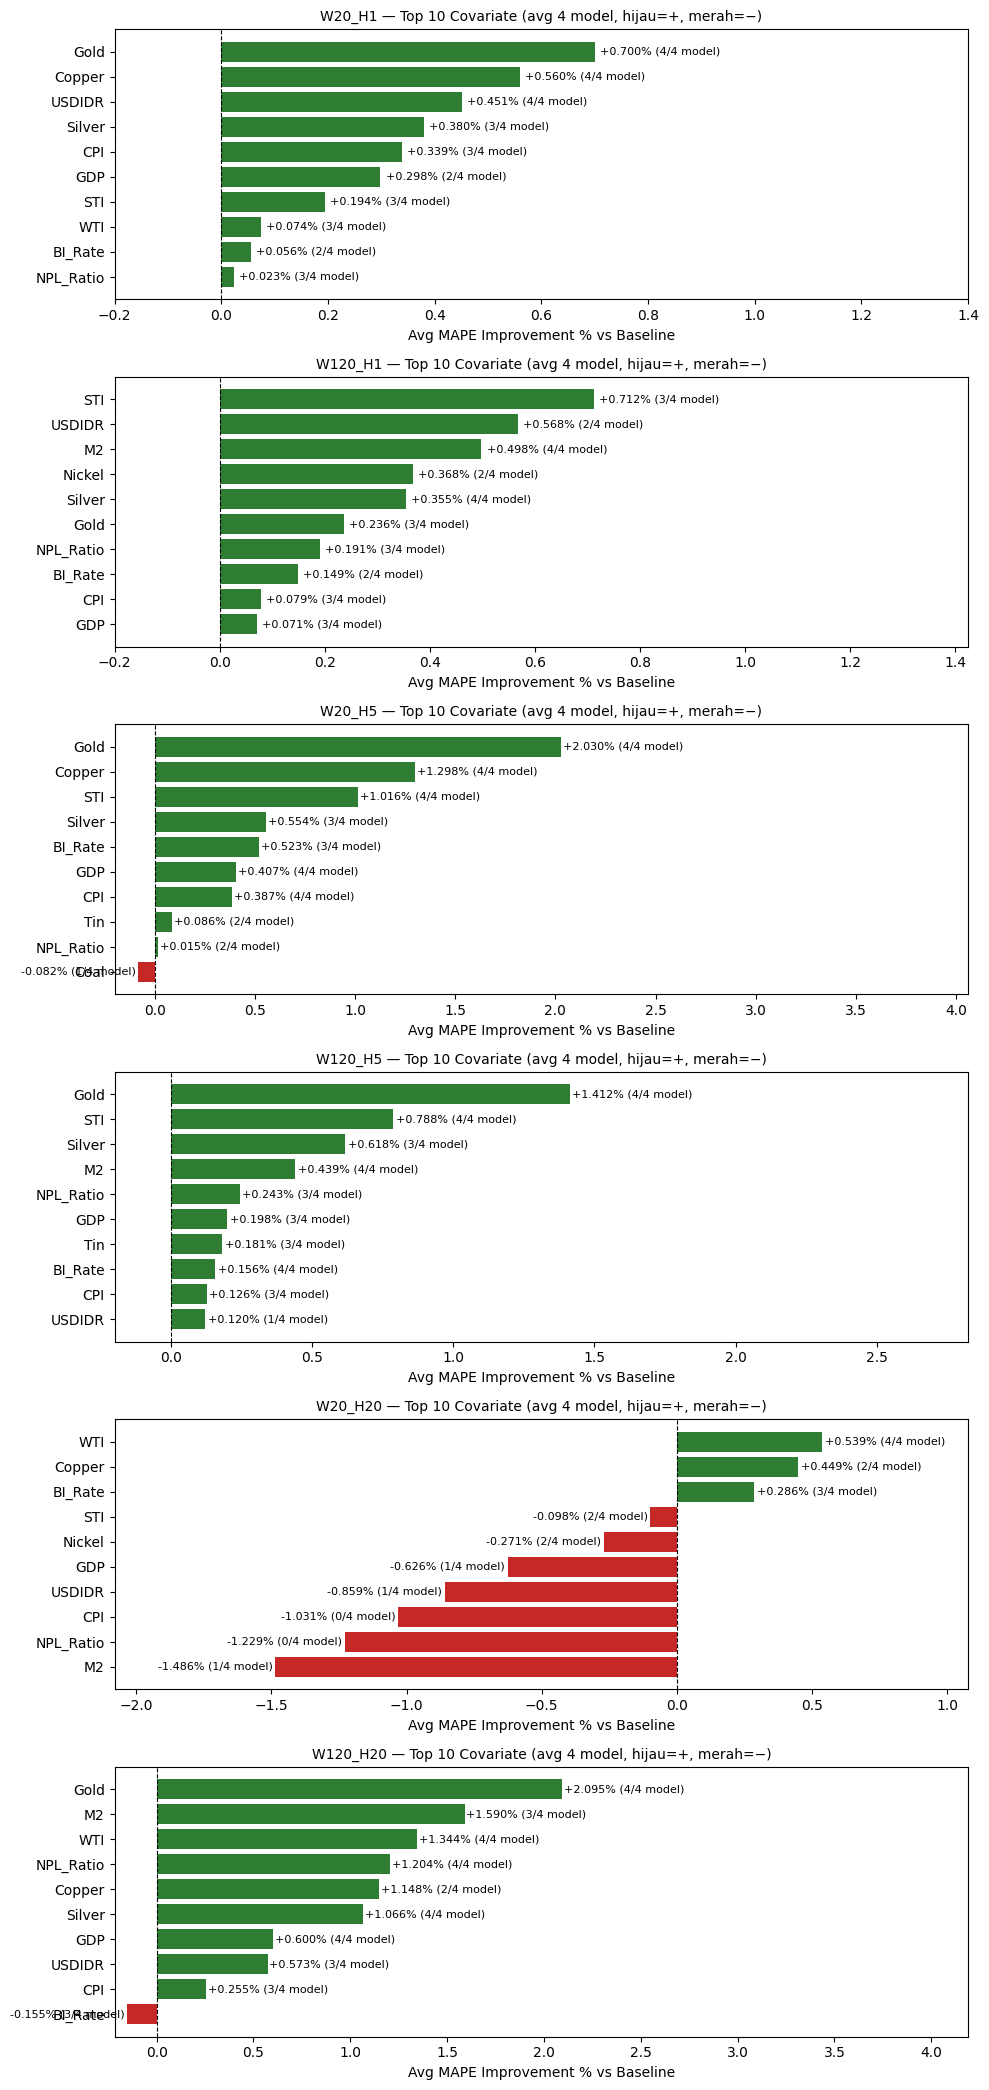

Saved: phase1_covariate_ranking_per_scenario.png

=== TABEL TOP 10 COVARIATE PER SKENARIO ===

W20_H1:
    Covariate  AvgMAPE_Impr  StdMAPE_Impr  AvgDA_Impr  N_Models_Positive  BestModel_Impr
1        Gold         0.700         1.065       0.315                  4           2.297
2      Copper         0.560         0.386       0.648                  4           0.986
3      USDIDR         0.451         0.417       1.158                  4           1.057
4      Silver         0.380         0.371       2.188                  3           0.817
5         CPI         0.339         0.596       0.812                  3           1.212
6         GDP         0.298         0.685       0.545                  2           1.296
7         STI         0.194         0.902       0.380                  3           1.339
8         WTI         0.074         0.598      -0.158                  3           0.747
9     BI_Rate         0.056         0.468      -0.027                  2           0.662
10  NPL

In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df_valid = df_results.dropna(subset=["MAPE_mean"]).copy()

# Hitung improvement tiap covariate vs baseline, per (Model, Window, Horizon)
rows_impr = []
for model_name in df_valid["Model"].unique():
    for window in df_valid["Window"].unique():
        for horizon in df_valid["Horizon"].unique():
            mask = (
                (df_valid["Model"]   == model_name) &
                (df_valid["Window"]  == window) &
                (df_valid["Horizon"] == horizon)
            )
            sub = df_valid[mask]
            bl  = sub[sub["Covariates"] == "None"]["MAPE_mean"]
            if bl.empty:
                continue
            bl_mape = bl.values[0]
            bl_da   = sub[sub["Covariates"] == "None"]["DA_mean"].values[0]

            for _, row in sub[sub["Covariates"] != "None"].iterrows():
                if pd.isna(row["MAPE_mean"]):
                    continue
                mape_impr = (bl_mape - row["MAPE_mean"]) / bl_mape * 100
                da_impr   = row["DA_mean"] - bl_da
                rows_impr.append({
                    "Model":          model_name,
                    "Window":         window,
                    "Horizon":        horizon,
                    "Covariate":      row["Covariates"],
                    "MAPE_mean":      row["MAPE_mean"],
                    "Baseline_MAPE":  bl_mape,
                    "MAPE_Impr_pct":  round(mape_impr, 4),
                    "DA_mean":        row["DA_mean"],
                    "DA_Impr_pp":     round(da_impr, 2),
                })

df_impr = pd.DataFrame(rows_impr)

# Agregasi per (Window, Horizon, Covariate): rata-rata & std improvement lintas 4 model
df_cov_rank = (
    df_impr.groupby(["Window", "Horizon", "Covariate"])
    .agg(
        AvgMAPE_Impr   = ("MAPE_Impr_pct", "mean"),
        StdMAPE_Impr   = ("MAPE_Impr_pct", "std"),
        AvgDA_Impr     = ("DA_Impr_pp",    "mean"),
        N_Models_Positive = ("MAPE_Impr_pct", lambda x: (x > 0).sum()),
        BestModel_Impr = ("MAPE_Impr_pct", "max"),
    )
    .round(3)
    .reset_index()
)

# Plot + tabel untuk setiap skenario
scenarios = sorted(
    df_cov_rank[["Window", "Horizon"]].drop_duplicates().itertuples(index=False),
    key=lambda x: (x.Horizon, x.Window),
)

fig_rows = len(scenarios)
fig, axes = plt.subplots(fig_rows, 1, figsize=(10, fig_rows * 3.5))
if fig_rows == 1:
    axes = [axes]

for ax, sc in zip(axes, scenarios):
    w, h = sc.Window, sc.Horizon
    sub = (
        df_cov_rank[(df_cov_rank["Window"] == w) & (df_cov_rank["Horizon"] == h)]
        .sort_values("AvgMAPE_Impr", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    colors_bar = ["#2e7d32" if v > 0 else "#c62828" for v in sub["AvgMAPE_Impr"]]
    bars = ax.barh(sub["Covariate"][::-1], sub["AvgMAPE_Impr"][::-1], color=colors_bar[::-1])
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    for bar, (_, row) in zip(bars, sub[::-1].iterrows()):
        xpos = bar.get_width()
        ha   = "left" if xpos >= 0 else "right"
        offset = 0.01 if xpos >= 0 else -0.01
        n_pos = int(row["N_Models_Positive"])
        ax.text(
            xpos + offset, bar.get_y() + bar.get_height() / 2,
            f"{xpos:+.3f}% ({n_pos}/4 model)",
            va="center", ha=ha, fontsize=8,
        )
    ax.set_xlabel("Avg MAPE Improvement % vs Baseline")
    ax.set_title(f"W{w}_H{h} — Top 10 Covariate (avg 4 model, hijau=+, merah=−)", fontsize=10)
    ax.set_xlim(
        min(sub["AvgMAPE_Impr"].min() * 1.4, -0.2),
        max(sub["AvgMAPE_Impr"].max() * 2.0,  0.2),
    )

plt.tight_layout()
plt.savefig("phase1_covariate_ranking_per_scenario.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: phase1_covariate_ranking_per_scenario.png")

# Tabel ringkas per skenario
print("\n=== TABEL TOP 10 COVARIATE PER SKENARIO ===")
for sc in scenarios:
    w, h = sc.Window, sc.Horizon
    sub = (
        df_cov_rank[(df_cov_rank["Window"] == w) & (df_cov_rank["Horizon"] == h)]
        .sort_values("AvgMAPE_Impr", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    sub.index += 1
    print(f"\nW{w}_H{h}:")
    print(sub[["Covariate", "AvgMAPE_Impr", "StdMAPE_Impr",
               "AvgDA_Impr", "N_Models_Positive", "BestModel_Impr"]].to_string())